# Experimento 15

## Entrenamiento con pipeline control

Incluimos en esta pipeline todas las aumentaciones con una probabilidad de 0.3 para comprarar los resultados con las seleccionadas tras el estudio.

In [1]:
from framework.framework_final import Persister, MetricsCalculator, AudioResNetModel, GSC, Preprocessor, Trainer, Evaluator, prepare_batch, plot_curves, show_image_grid, signal_grad_cam_overlays2d
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
from typing import List, Dict, Any, Optional
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from signal_grad_cam.pytorch_cam_builder import TorchCamBuilder

I0000 00:00:1781123839.187593    7397 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781123839.218789    7397 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781123840.033505    7397 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781123840.033764    7397 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
AUDIO_PATH = Path('/mnt/data/GSC/normalized-dataset')
XTRAIN_PATH = Path('./dataframes/FASE2-X_train.csv')
XTEST_PATH = Path('./dataframes/FASE2-X_test.csv')
XVAL_PATH = Path('./dataframes/FASE2-X_val.csv')
YVAL_PATH = Path('./dataframes/FASE2-y_val.csv')
YTRAIN_PATH = Path('./dataframes/FASE2-y_train.csv')
YTEST_PATH = Path('./dataframes/FASE2-y_test.csv')
BACKGROUND_NOISES = sorted(Path(f"/mnt/data/GSC/speech_commands_v0.02/_background_noise_/").glob('*wav'))

NUM_CLASSES = 35

DEVICE = 'cuda'

# Cambios MELs
SAMPLE_RATE = 16000
N_MELS =128
N_FFT = int(768)
WIN_LENGTH = N_FFT
HOP_LENGTH = int(100)

In [3]:
final_path = '15-entrenamiento_2D_pipeline_control/final'
checkpoints_path = '15-entrenamiento_2D_pipeline_control/checkpoints'
xai_path = Path('/mnt/data/GSC/XAI/15-entrenamiento_2D_pipeline_control')
batch_size = 200
epochs = 10

In [4]:
%%capture
# Instanciación del framework
persister = Persister(final_path=final_path, checkpoints_path=checkpoints_path, xai_path=xai_path)
preprocessor_train = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,
        with_log = True,
        device = DEVICE,
        mode = "training",
        augmentation_probs = {
            "time_shift" : 0.3,
            "frequency_masking" : 0.3,
            "additive_noise" : 0.3,
            "random_gain" : 0.3,
            "time_stretch" : 0.3,
            "speed_perturb" : 0.3,
            "mix_background" : 0.3,
            "basic_eq_and_compress": 0.3,
            "reverb" : 0.3,
            "time_masking" : 0.3})

preprocessor_test = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,    
        with_log = True,
        device = DEVICE)
# Modelo
model = AudioResNetModel(dims=2, num_classes=NUM_CLASSES).get_model()
model.to(DEVICE)

In [5]:
# Conjuntos de datos
X_train = pd.read_csv(XTRAIN_PATH)
X_test = pd.read_csv(XTEST_PATH)
y_train = pd.read_csv(YTRAIN_PATH)
y_test = pd.read_csv(YTRAIN_PATH)
X_val = pd.read_csv(XVAL_PATH)                                                                                                          
y_val = pd.read_csv(YVAL_PATH)                                                                                                          

le = LabelEncoder()

y_encoded = le.fit_transform(y_train['keyword'])
ytest_encoded = le.transform(y_test['keyword'])
yval_encoded = le.transform(y_val['keyword'])

label_names= le.classes_

train_list = X_train['path_normalized'].tolist()                                                                                            
train_labels = y_encoded.tolist() 
val_list = X_val['path_normalized'].tolist()                                                                                            
val_labels = yval_encoded.tolist() 
test_list = X_test['path_normalized'].tolist()
test_labels = ytest_encoded.tolist()

train_dataset = GSC(file_list=train_list, labels=train_labels)
validation_dataset = GSC(file_list=val_list, labels=val_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=prepare_batch, num_workers=4)
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, collate_fn=prepare_batch, num_workers=4)
test_dataset = GSC(test_list, test_labels)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 4)

In [8]:
trainer = Trainer(model=model, train_loader=train_loader, val_loader=val_loader, preprocessor=preprocessor_train, persister=persister, device=DEVICE, epochs=epochs)                    
trainer.fit(resume=False)

Epoch::   0%|          | 0/10 [00:00<?, ?it/s]

Batches entrenamiento:   0%|          | 0/371 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 1/10
  Train - Pérdida: 0.7411, Accuracy: 0.7885, F1-score: 0.7800
  Val   - Pérdida: 0.5344, Accuracy: 0.8399, F1-score: 0.8333


Batches entrenamiento:   0%|          | 0/371 [00:00<?, ?it/s]

...

Batches validación:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 9/10
  Train - Pérdida: 0.1344, Accuracy: 0.9577, F1-score: 0.9549
  Val   - Pérdida: 0.2625, Accuracy: 0.9220, F1-score: 0.9158


Batches entrenamiento:   0%|          | 0/371 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 10/10
  Train - Pérdida: 0.1234, Accuracy: 0.9610, F1-score: 0.9579
  Val   - Pérdida: 0.2790, Accuracy: 0.9218, F1-score: 0.9177


In [6]:
learning_rate = 1e-4
trainer = Trainer(model=model, learning_rate=learning_rate, train_loader=train_loader, val_loader=val_loader, preprocessor=preprocessor_train, persister=persister, device=DEVICE, epochs=epochs+10, resume_from=f"{final_path}/final_model.pt")                    
trainer.fit(resume=True)

Cargado desde 15-entrenamiento_2D_pipeline_control/final/final_model.pt. Comenzamos en epoch 11
Cargado desde 15-entrenamiento_2D_pipeline_control/final/final_model.pt. Comenzamos en epoch 11


Epoch::   0%|          | 0/10 [00:00<?, ?it/s]

Batches entrenamiento:   0%|          | 0/371 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 11/20
  Train - Pérdida: 0.0784, Accuracy: 0.9761, F1-score: 0.9742
  Val   - Pérdida: 0.1784, Accuracy: 0.9487, F1-score: 0.9441


...

Batches validación:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 19/20
  Train - Pérdida: 0.0442, Accuracy: 0.9869, F1-score: 0.9858
  Val   - Pérdida: 0.1897, Accuracy: 0.9510, F1-score: 0.9471


Batches entrenamiento:   0%|          | 0/371 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 20/20
  Train - Pérdida: 0.0415, Accuracy: 0.9873, F1-score: 0.9866
  Val   - Pérdida: 0.1899, Accuracy: 0.9502, F1-score: 0.9462


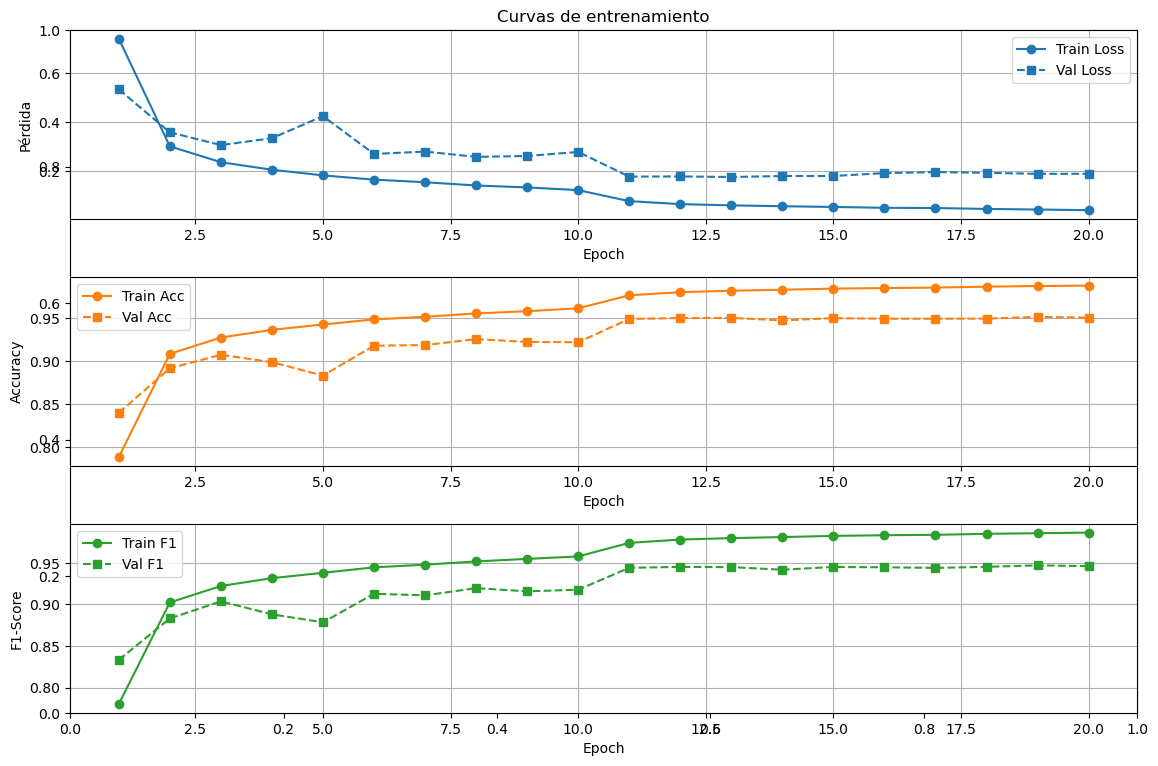

In [6]:
# Evaluación del modelo
# Cargamos desde el disco para poder evaluar en cualquier momento
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=2, num_classes=35).get_model()
loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

plot_curves(loaded_pt, 'Curvas de entrenamiento')

In [7]:
df = pd.DataFrame(loaded_pt['history'])
df.index = df.index+1
print(df)

    train_loss  train_acc  train_f1  val_loss   val_acc    val_f1  epoch_time
1     0.741064   0.788521  0.779984  0.534410  0.839917  0.833270  260.124187
2     0.301990   0.908238  0.902444  0.358988  0.891514  0.883121  260.735167
3     0.237201   0.927122  0.922255  0.306991  0.907201  0.903781  260.802366
4     0.206407   0.936031  0.931688  0.334956  0.898601  0.888170  260.633109
5     0.183464   0.942294  0.938137  0.425051  0.883103  0.878536  261.249913
6     0.166032   0.948153  0.944721  0.270831  0.917690  0.912889  260.860344
7     0.155541   0.951217  0.947939  0.280504  0.918446  0.910979  261.210114
8     0.142203   0.955091  0.951839  0.258949  0.925345  0.919650  261.304716
9     0.134357   0.957710  0.954907  0.262455  0.922037  0.915840  261.120988
10    0.123358   0.961017  0.957896  0.279006  0.921754  0.917741  260.357790
11    0.078395   0.976108  0.974160  0.178384  0.948686  0.944149  261.857492
12    0.066251   0.979698  0.978197  0.179136  0.949726  0.94527

Vemos que el modelo con la pipeline de control también ha obtenido unos buenos resultados. Se aprecia en las curvas un punto de inflexión en la epoch 11 que corresponde con la disminución del learning rate de 1e-3 a 1e-4.
Ene este caso la mejor epoch es la 19, que procedemos a cargar:

In [9]:
%%capture
# Mejor modelo (F1 val)
# Cargamos epoch 27
loaded_pt = torch.load(f"{checkpoints_path}/best_checkpoint_epoch_19.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=2, num_classes=35).get_model()
loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

**Análisis del entrenamiento**

El margen entre la curva de train y la curva de val es ligeramente mayor que en el caso anterior, lo que puede indicar un sobreajuste ligeramente más importante.

In [10]:
# Instanciamos el evaluador y computamos métricas
evaluator = Evaluator(model=loaded_model, device=DEVICE, test_loader=test_loader, preprocessor = preprocessor_test)
confusion_matrix, precission, recall, avg_loss, accuracy, f1, support = evaluator.eval()
print("Pérdida:", avg_loss, "Accuracy:", accuracy, "F1-Score:", f1)

Batches evaluación:   0%|          | 0/53 [00:00<?, ?it/s]

Pérdida: 0.5899180385267052 Accuracy: 0.9352674352674353 F1-Score: 0.9309599234070319


In [11]:
# Ratio entre f1 test y f1 en val
print("Ratio test/val F1:", f1/loaded_pt['history'].get('val_f1')[18])
print("Ratio test/val Accuracy:", accuracy/loaded_pt['history'].get('val_acc')[18])

Ratio test/val F1: 0.9829222588444496
Ratio test/val Accuracy: 0.983406200317965


Las métricas son muy buenas y sólo marginalmente peores que en la pipeline anterior. El ratio de generalización de val a test también es muy bueno.

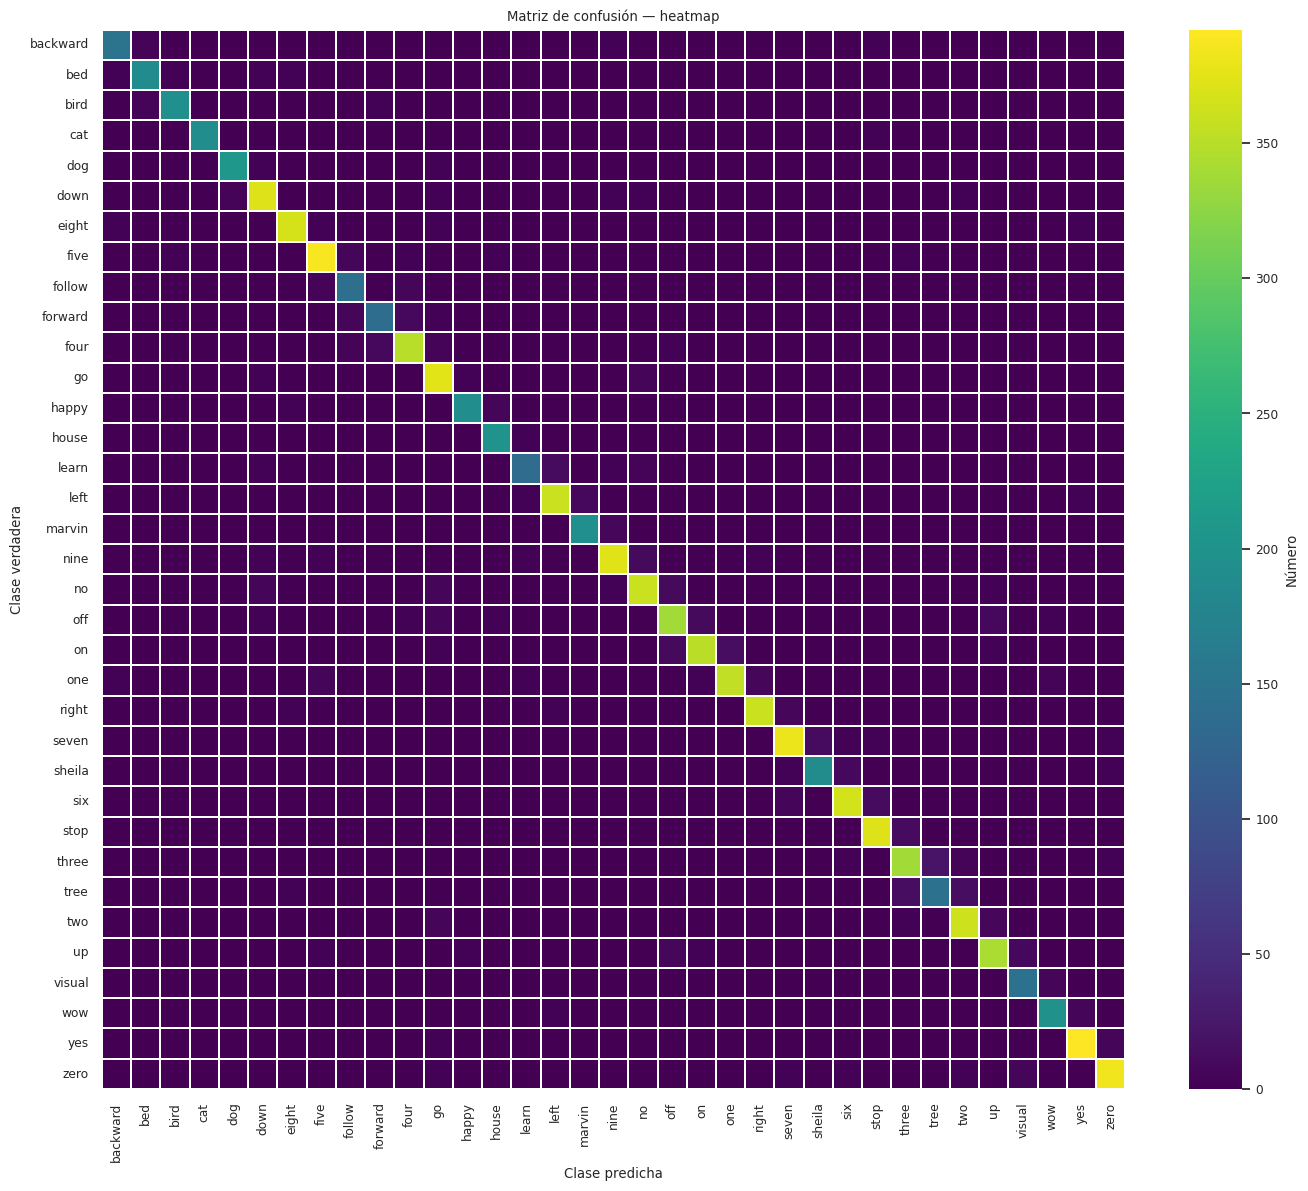

In [12]:
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize = (14,12))
sb.set(font_scale = 0.8)
ax = sb.heatmap(confusion_matrix,
                annot=False,
                fmt = ".2f",
                cmap = "viridis",
                cbar_kws = {"label": "Número"},
                xticklabels = label_names,
                yticklabels = label_names,
                linewidths = 0.3,
                linecolor = "white")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.xlabel("Clase predicha")
plt.ylabel("Clase verdadera")
plt.title("Matriz de confusión — heatmap")
plt.tight_layout()
plt.show()
plt.rcdefaults()

No se aprecia ninguna concentración de errores especialmente llamativa.

In [13]:
print("Métricas con test set:",
      "\n\nAccuracy:", accuracy, 
      "\nPrecission:", precission, 
      "\nRecall:", recall, 
      "\nPérdida media:", avg_loss, 
      "\nF1-score:", f1)

Métricas con test set: 

Accuracy: 0.9352674352674353 
Precission: 0.9313607291901225 
Recall: 0.9308097602562879 
Pérdida media: 0.5899180385267052 
F1-score: 0.9309599234070319


Todas las métricas siguen siendo aceptables, si bien marginalmente inferiores al modelo anterior, pero no muy significativamente.

In [14]:
## Signal_grad_cam: Preparamos los datos
reference_samples = ['/mnt/data/GSC/normalized-dataset/go/012c8314_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/off/0227998e_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/left/016e2c6d_nohash_0.wav']
reference_labels = [11,19,15]

reference_dataset = GSC(reference_samples, reference_labels)
reference_loader = DataLoader(reference_dataset, batch_size = 3, shuffle = False, 
                              collate_fn = prepare_batch, num_workers = 4)

reference_targets = [11,19,15]

In [15]:
%%capture
## Generamos los CAMs
target_layers = ['layer4.1.conv2', 'layer4.0.conv2', 
                 'layer3.1.conv2', 'layer3.0.conv2', 
                 'layer2.1.conv2', 'layer1.1.conv2']

explainer = "Grad-CAM"

signal_grad_cam_overlays2d(model=loaded_model, dataloader=reference_loader, preprocessor=preprocessor_test,
                          xai_path=xai_path, label_names=label_names, explainer=explainer,
                          target_layers=target_layers, target_classes=reference_labels, 
                          targets_list=reference_targets)

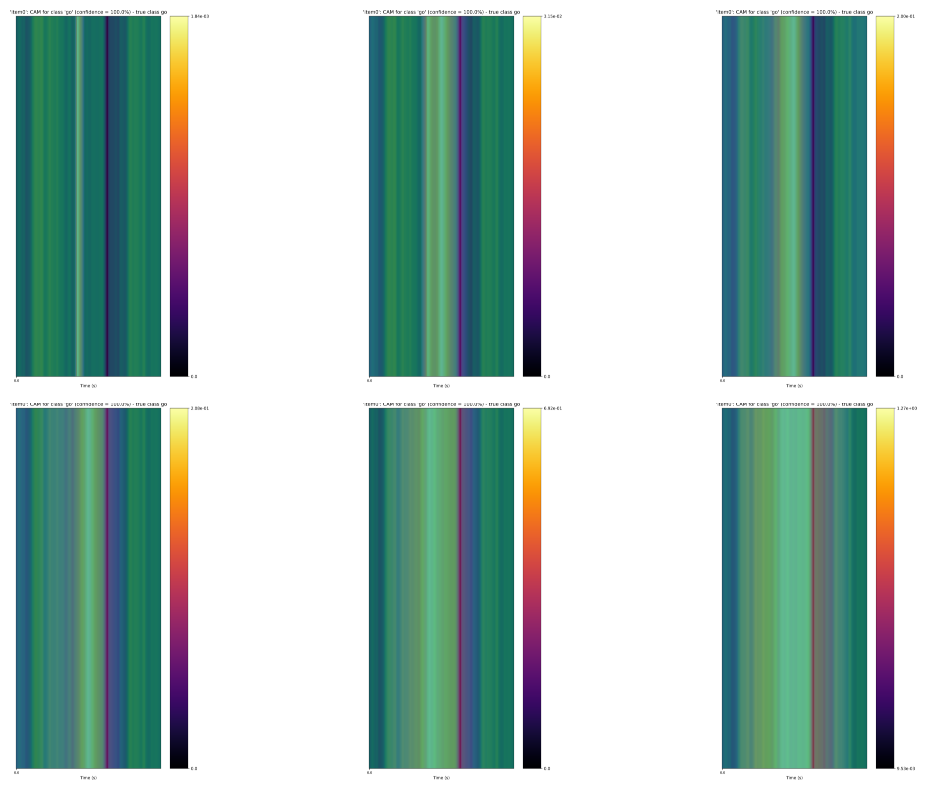

In [16]:
## Visualizamos muestra de capas
# "GO"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*Grad*.png"))
show_image_grid(images_to_show)

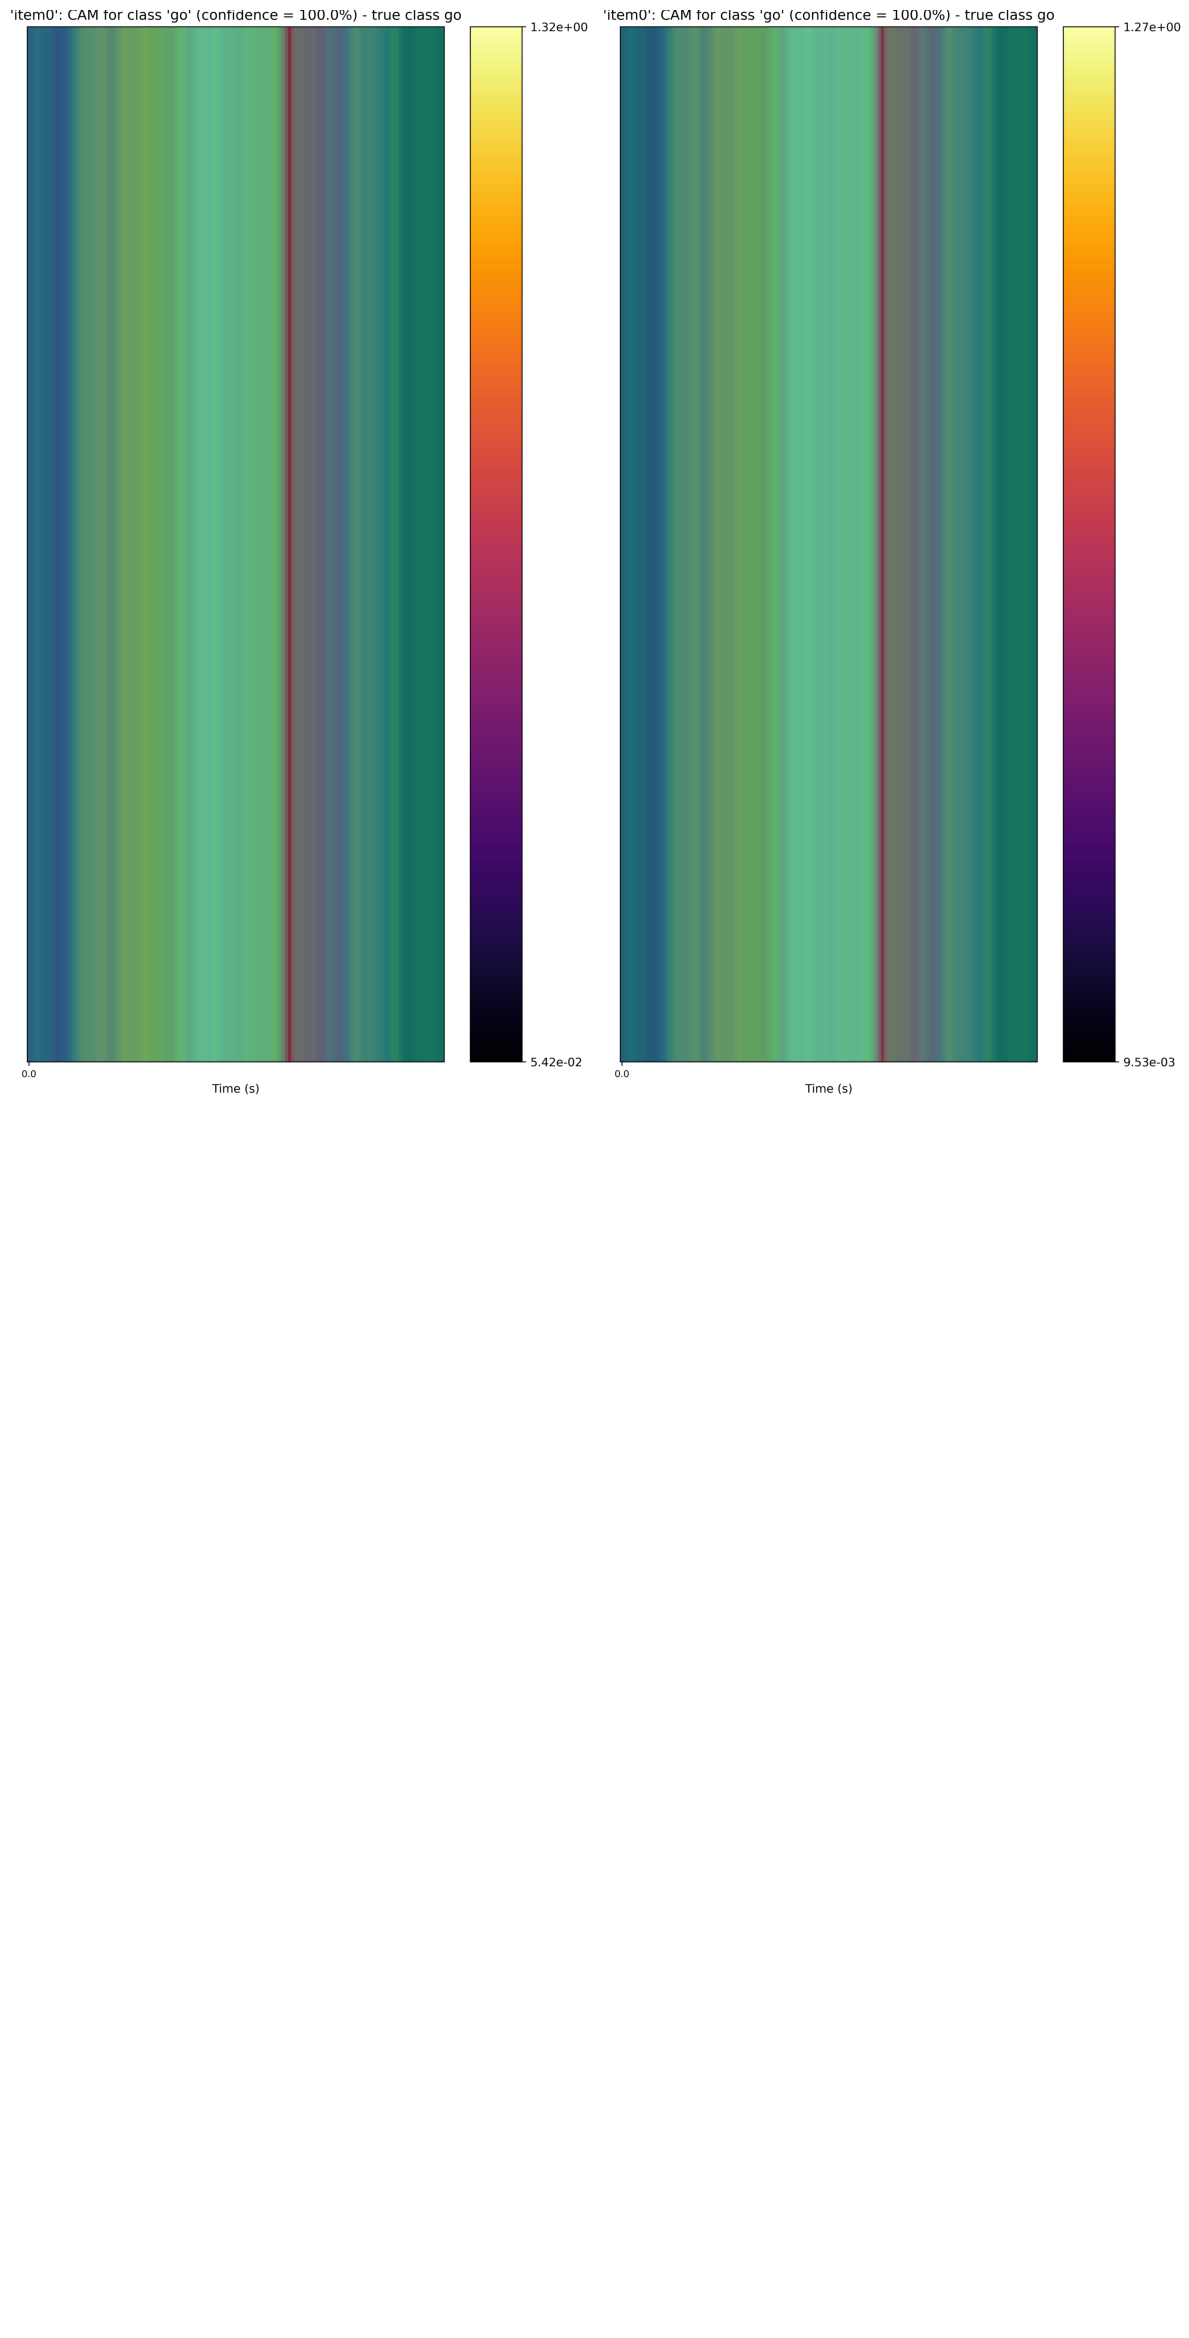

In [17]:
# CAM "GO"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18_02/CAMs/overlays/0-2/item0/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

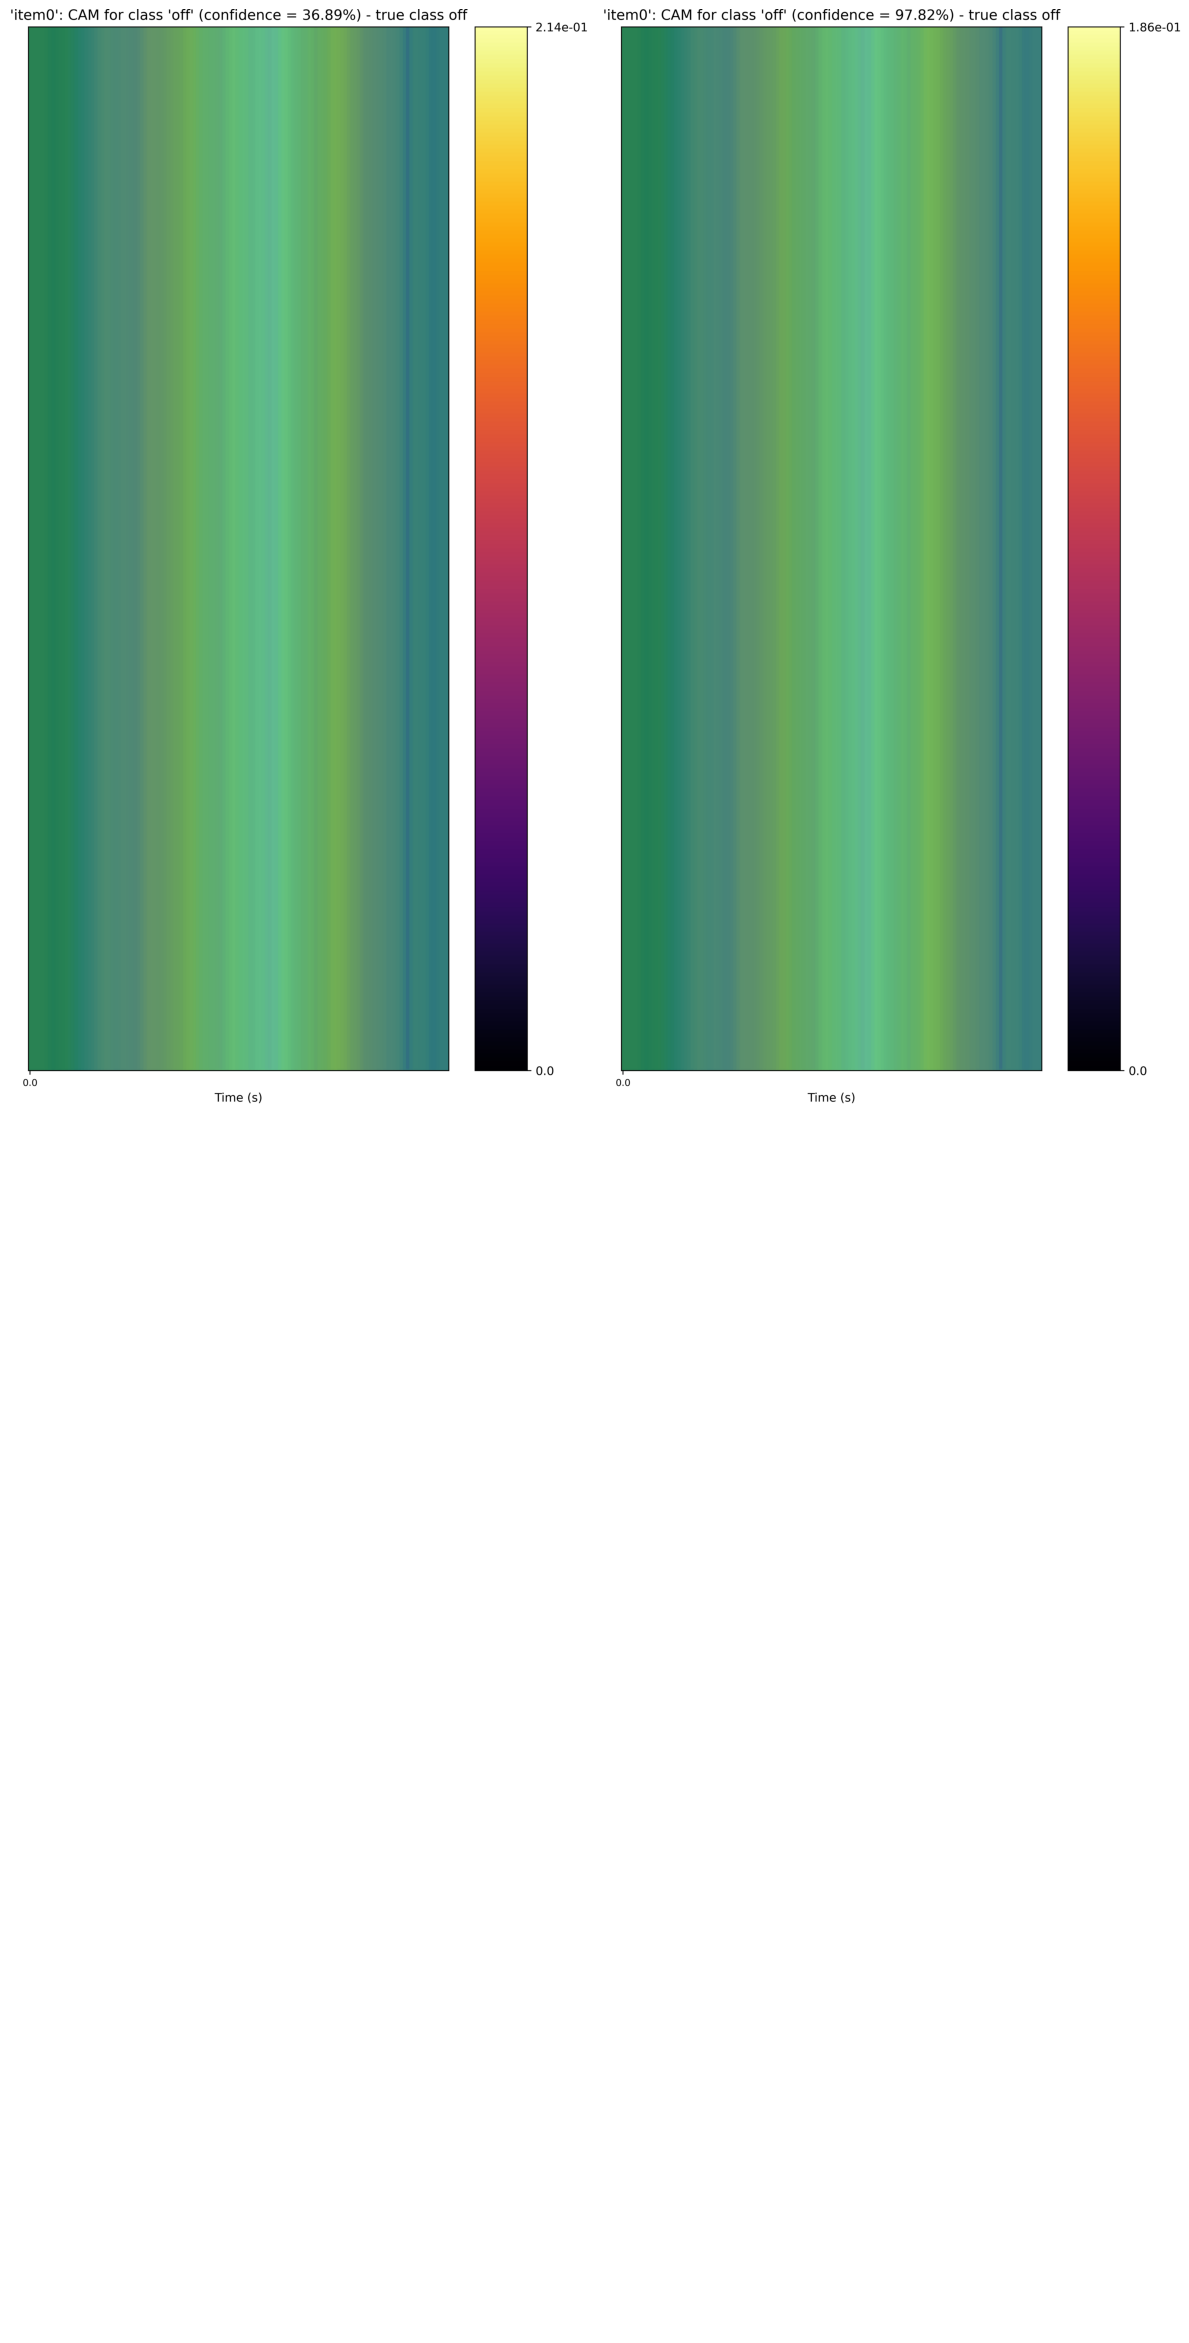

In [18]:
# CAM "OFF"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18_02/CAMs/overlays/0-2/item1/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item1/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

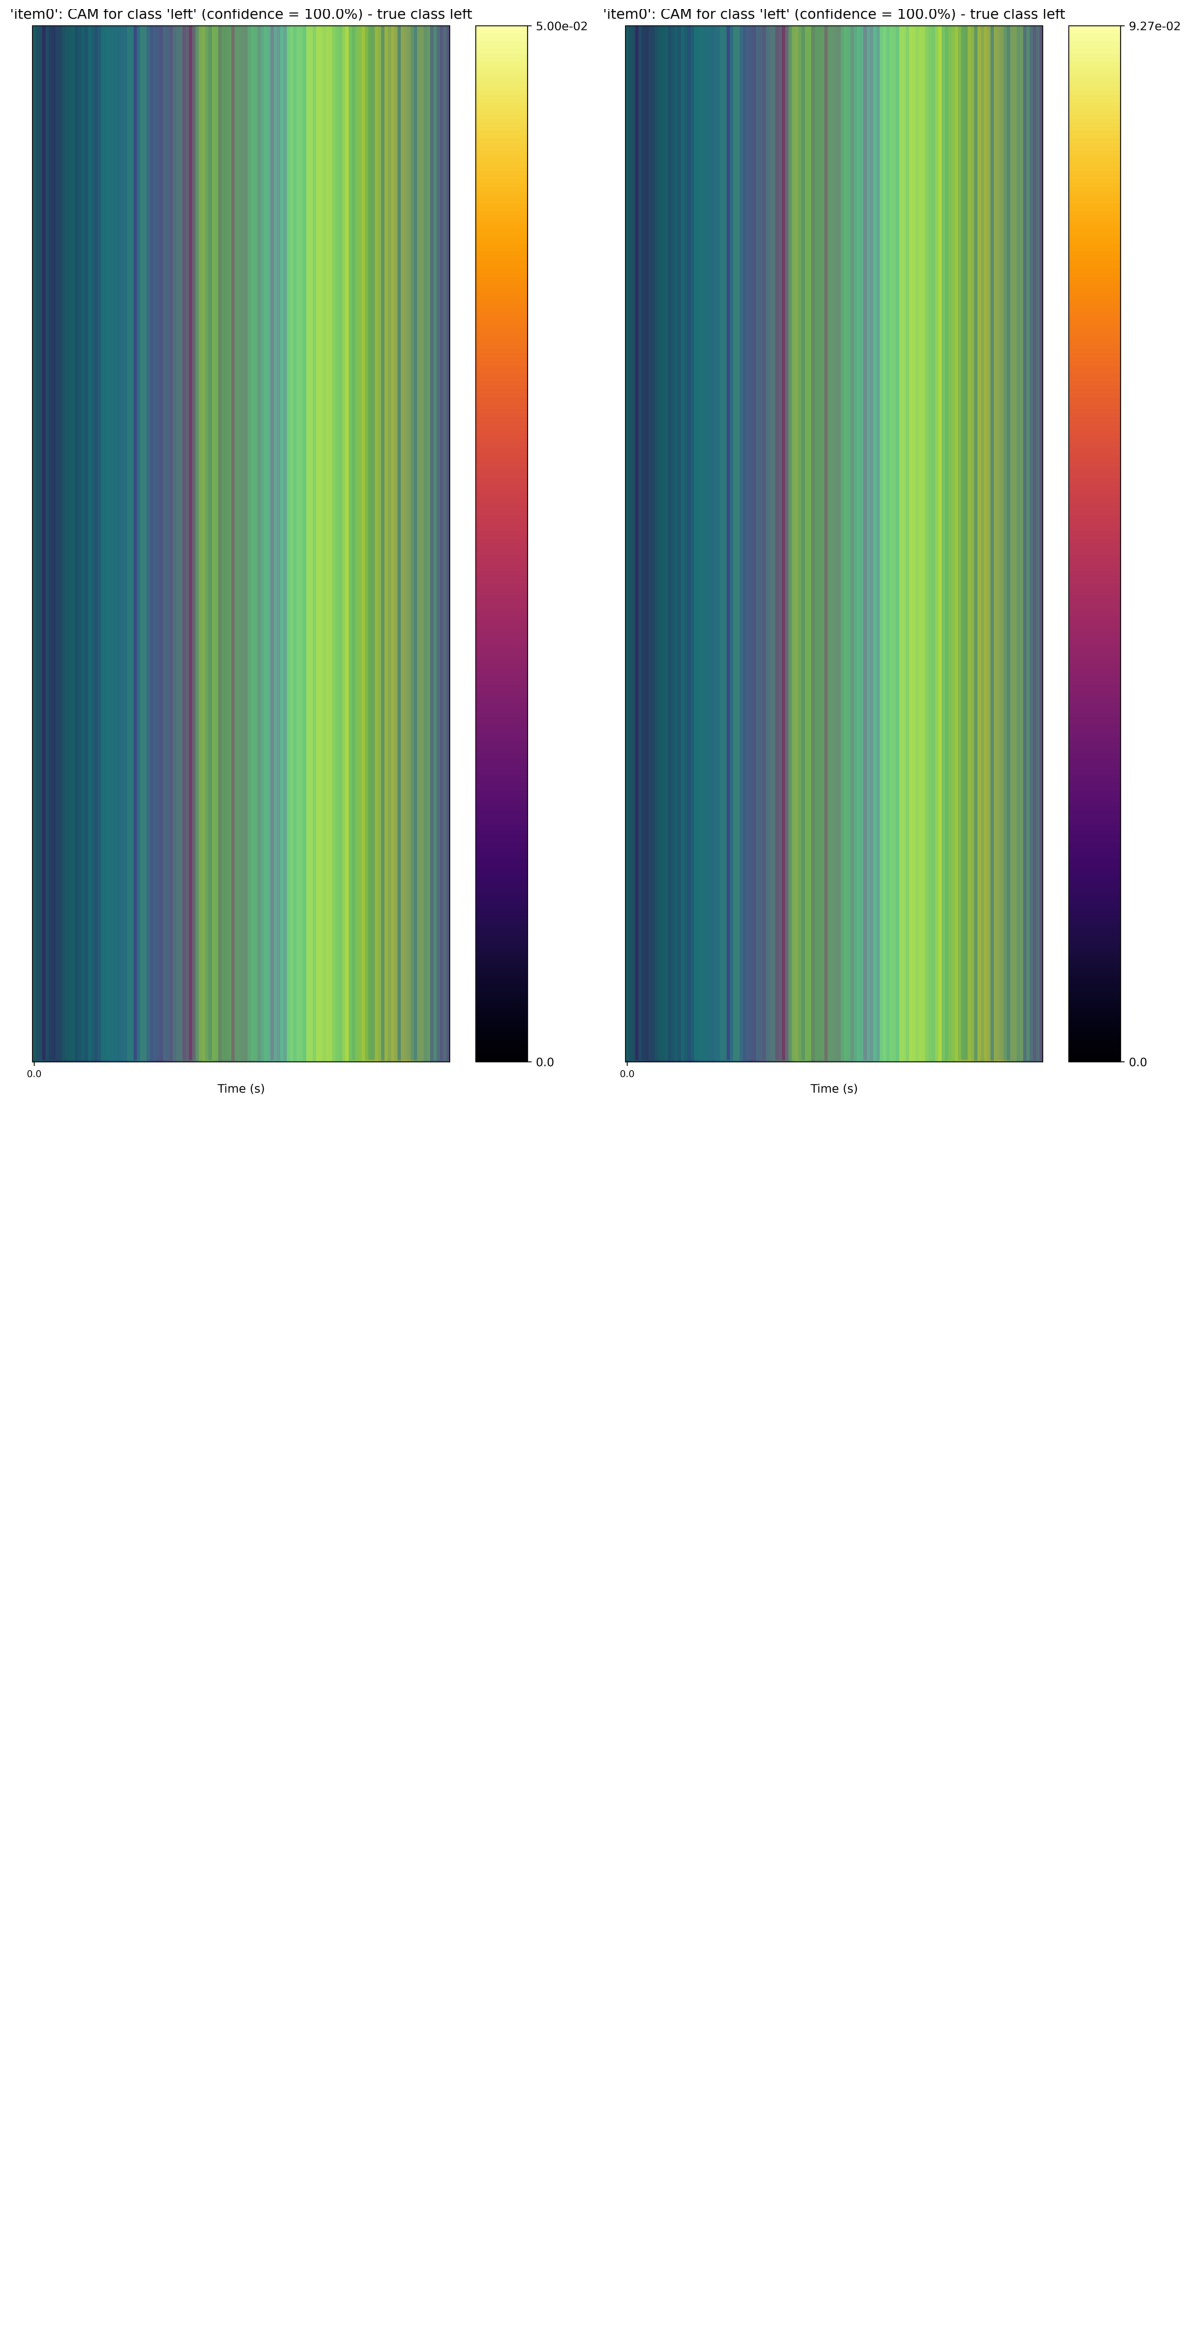

In [19]:
# CAM "LEFT"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18_02/CAMs/overlays/0-2/item2/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item2/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

La atención del modelo es consistente con la del modelo de referencia y la confiana en nuestra muestra de contraste OFF ha crecido de manera similar a la pipeline anterior.

Finalmente, vamos a estimar el coste de entrenamiento a partir del tiempo medio por epoch.

In [20]:
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
etimes = loaded_pt['history'].get('epoch_time')
avg_etime = sum(etimes)/len(etimes)
print(avg_etime)
baseline_etime = 155.78
print("El coste en tiempo por epoch es de", f"{avg_etime/baseline_etime:.2f}", "veces el de la línea de base (v2).")     

260.5926500320435
El coste en tiempo por epoch es de 1.67 veces el de la línea de base (v2).


**Conclusiones:**

Durante los estudios previos se ha identificado una tendencia al sobreajuste en el entrenamiento que se ha abordado con un decremento del learning rate y la inclusión de gran variedad de aumentaciones. Se han preparado dos pipelines con aumentaciones: una seleccionada y otra que las incluye todas en una proporción similar. Ambas han contribuido en la mejora de confianza en la identificación de los monosílabos, fuertemente ligada a las diferencias de contenido de intensidad y frecuencia referenciadas a la envolvente temporal, si bien la pipeline seleccionada tiene un menor coste estimado de entrenamiento y unas métricas marginalmente mejores. La selección se ha tomado cruzando el incremento en las métricas cuantitativas de rendimiento obtenidas durante los experimentos y selecionando las aumentaciones que mejor relación cote/beneficio han aportado en esa fase, con el apoyo de la métrica de confianza proporcionada por SignalGrad-CAM y una evaluación cualitativa de los CAMs superpuestos con los espectrogrmas. 

En este contexto, en el que la diferencia entre la pipeline seleccionada y la pipeline de control es tan pequeña, se toman como significativas las diferencias marginales que han aparecido en el análisis contrastivo y que parecen indicar que la interpretación de los datos es coherente con los resultados obtenidos.

Gracias a la visualización de SignalGrad-CAM se ha identificado, además, un problema en la representación de espectrogramas de mayor dimensionalidad planteada en las primeras fases de análisis y gracias a ello se ha podido actuar a tiempo de reconducir el trabajo en el tiempo previsto.

Se estima, por tanto, que la información obtenida por XAI con esta implementación de GradCAM ha sido crítica para la buena consecución del proyecto.

En cuanto a la adecuación de ResNet18 para los propósitos del estudio, ha resultado ser un modelo muy eficiente. Los resultados ya en la línea de base han sido muy buenos y si extrapolamos los resultados a las redes residuales, se recomienda su uso para este tipo de clasificaiones en entornos de recursos computacionales limitados.

En cuanto al modelo final obtenido en la pipeline con la selecciónd e aumentaciones, mejora el de la línea de base por un margen considerable dadas las altas métricas de base de contraste que se han obtenido en el inicio, y con un coste por epoch muy razonable.
  